# Race Chaos & Predictability

## Motivation

Formula 1 races are not equally predictable.
Some races follow a clear and expected pattern, while others are shaped by chaos: retirements, incidents, weather conditions, and unexpected results.

In previous notebooks, we analyzed individual components such as DNFs, finishing rates, and position distributions.
This notebook brings those elements together and shifts the focus **from drivers and seasons to individual races**.

The goal is to quantify **how chaotic or predictable a race is**, and to compare races, tracks, seasons, and conditions using unified metrics.

---

## What This Notebook Does

In this notebook, we:
- work at **race-level granularity** (one row = one race)
- compute core race metrics such as:
  - DNF rate
  - finishing rate
  - position volatility
- use these metrics as a foundation for defining **race chaos and predictability**
- prepare the data for further aggregation (by track, year, weather)

This notebook does **not** focus on individual driver performance.
Instead, it treats each race as a single event with measurable stability or randomness.

---

## Key Question
> Which circuits are historically associated with more DNFs?
>
>
> How did the causes of DNFs change across eras?
>
> Are DNFs driven by accidents or mechanical failures?
>
> How chaotic or predictable was a given Formula 1 race?


In [1]:
from copyreg import constructor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data
from src.data_overview import overview_dataframe
from src.plots import plot_dnf_percent_by_circuits

In [2]:
results = load_data('results')
races = load_data('races')
status = load_data('status')
constructors = load_data('constructors')
circuits = load_data('circuits')

In [3]:
df = (
    results
    .merge(races[['raceId', 'year', 'name', 'circuitId']], on='raceId', how='left')
    .merge(status, on='statusId', how='left')
)

df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,name,circuitId,status
0,1,18,1,1,22,1,1,1,1,10.0,...,5690616,39,2,1:27.452,218.3,1,2008,Australian Grand Prix,1,Finished
1,2,18,2,2,3,5,2,2,2,8.0,...,5696094,41,3,1:27.739,217.586,1,2008,Australian Grand Prix,1,Finished
2,3,18,3,3,7,7,3,3,3,6.0,...,5698779,41,5,1:28.090,216.719,1,2008,Australian Grand Prix,1,Finished
3,4,18,4,4,5,11,4,4,4,5.0,...,5707797,58,7,1:28.603,215.464,1,2008,Australian Grand Prix,1,Finished
4,5,18,5,1,23,3,5,5,5,4.0,...,5708630,43,1,1:27.418,218.385,1,2008,Australian Grand Prix,1,Finished


In [4]:
from config.dnf_groups import STATUS_FINISHED
status_mapping = {}
for group_name, ids in STATUS_FINISHED.items():
    for s_id in ids:
        status_mapping[s_id] = group_name

df['statusGroup'] = df['statusId'].map(status_mapping)

df

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,name,circuitId,status,statusGroup
0,1,18,1,1,22,1,1,1,1,10.0,...,39,2,1:27.452,218.3,1,2008,Australian Grand Prix,1,Finished,Finished
1,2,18,2,2,3,5,2,2,2,8.0,...,41,3,1:27.739,217.586,1,2008,Australian Grand Prix,1,Finished,Finished
2,3,18,3,3,7,7,3,3,3,6.0,...,41,5,1:28.090,216.719,1,2008,Australian Grand Prix,1,Finished,Finished
3,4,18,4,4,5,11,4,4,4,5.0,...,58,7,1:28.603,215.464,1,2008,Australian Grand Prix,1,Finished,Finished
4,5,18,5,1,23,3,5,5,5,4.0,...,43,1,1:27.418,218.385,1,2008,Australian Grand Prix,1,Finished,Finished
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27233,27239,1168,848,3,23,17,16,16,16,0.0,...,45,12,1:28.367,\N,1,2025,Abu Dhabi Grand Prix,24,Finished,Finished
27234,27240,1168,865,215,6,9,17,17,17,0.0,...,52,20,1:29.375,\N,11,2025,Abu Dhabi Grand Prix,24,+1 Lap,Finished
27235,27241,1168,859,215,30,13,18,18,18,0.0,...,39,16,1:28.886,\N,11,2025,Abu Dhabi Grand Prix,24,+1 Lap,Finished
27236,27242,1168,842,214,10,19,19,19,19,0.0,...,46,8,1:27.767,\N,11,2025,Abu Dhabi Grand Prix,24,+1 Lap,Finished


In [5]:
race_results_summary = (
    df
    .groupby('raceId')
    .agg(
        year=('year', 'first'),
        race_name=('name', 'first'),
        circuitId=('circuitId', 'first'),
        finished_count=('statusGroup', lambda x: (x == 'Finished').sum()),
        dnf_count=('statusGroup', lambda x: (x == 'DNF').sum()),
        notfinished_count=('statusGroup', lambda x: (x == 'NotFinishedNotDNF').sum()),
        total_entries=('statusGroup', 'size')
    )
    .reset_index()
)
race_results_summary['total_started'] = race_results_summary['finished_count'] + race_results_summary['dnf_count']

race_results_summary = race_results_summary[
    ['year', 'race_name', 'circuitId','total_started', 'finished_count', 'dnf_count', 'notfinished_count', 'total_entries']
]

race_results_summary.head()

,year,race_name,circuitId,total_started,finished_count,dnf_count,notfinished_count,total_entries
0,2009,Australian Grand Prix,1,20,12,8,0,20
1,2009,Malaysian Grand Prix,2,20,15,5,0,20
2,2009,Chinese Grand Prix,17,20,16,4,0,20
3,2009,Bahrain Grand Prix,3,20,19,1,0,20
4,2009,Spanish Grand Prix,4,20,14,6,0,20


In [6]:
from pathlib import Path
out_path = Path("../data/processed/race_results_summary.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
race_results_summary.to_csv(out_path, index=False)

## Race Results Summary

At this stage, we aggregate race-level outcomes to create a clean and consistent
representation of each Formula 1 race as a single event.

Each row in the table corresponds to **one race** and summarizes:
- how many drivers actually started the race,
- how many finished,
- how many retired during the race (DNF).

### Definitions

- **total_started**: number of drivers who started the race
  (Finished + DNF only; non-starters are excluded)

- **finished_count**: number of drivers classified as *Finished*

- **dnf_count**: number of drivers who retired during the race (DNF)

Statuses such as *NotFinishedNotDNF* (e.g. did not start, excluded, not qualified)
are intentionally excluded from the analysis, as they do not reflect race dynamics.

This table serves as the foundational race-level layer for further analysis of
race chaos, incidents, and predictability.


In [7]:
race_results_summary = pd.read_csv("../data/processed/race_results_summary.csv")
race_results_summary = race_results_summary.merge(circuits[['circuitId', 'name', ]], on='circuitId', how='left')
race_results_summary = race_results_summary.rename(columns = {'name':'circuitName'})
race_results_summary

,year,race_name,circuitId,total_started,finished_count,dnf_count,notfinished_count,total_entries,circuitName
0,2009,Australian Grand Prix,1,20,12,8,0,20,Albert Park Grand Prix Circuit
1,2009,Malaysian Grand Prix,2,20,15,5,0,20,Sepang International Circuit
2,2009,Chinese Grand Prix,17,20,16,4,0,20,Shanghai International Circuit
3,2009,Bahrain Grand Prix,3,20,19,1,0,20,Bahrain International Circuit
4,2009,Spanish Grand Prix,4,20,14,6,0,20,Circuit de Barcelona-Catalunya
...,...,...,...,...,...,...,...,...,...
1144,2025,Mexico City Grand Prix,32,20,16,4,0,20,Autódromo Hermanos Rodríguez
1145,2025,São Paulo Grand Prix,18,20,17,3,0,20,Autódromo José Carlos Pace
1146,2025,Las Vegas Grand Prix,80,20,15,5,0,20,Las Vegas Strip Street Circuit
1147,2025,Qatar Grand Prix,78,20,16,4,0,20,Losail International Circuit


In [8]:
race_results_summary['dnf_percent'] = ((race_results_summary['dnf_count'] / race_results_summary['total_started']) * 100).round(2)
race_results_summary.columns

Index(['year', 'race_name', 'circuitId', 'total_started', 'finished_count',
       'dnf_count', 'notfinished_count', 'total_entries', 'circuitName',
       'dnf_percent'],
      dtype='str')

In [9]:
circuits_dnf = (
    race_results_summary
    .groupby('circuitId')
    .agg(
        circuitName=('circuitName', 'first'),
        total_started=('total_started', 'sum'),
        dnf_count=('dnf_count', 'sum'),
        num_races=('race_name', 'count')
    )
    .reset_index()
)
circuits_dnf['dnf_percent'] = (
    circuits_dnf['dnf_count'] / circuits_dnf['total_started'] * 100
).round(2)

circuits_dnf = circuits_dnf[circuits_dnf['num_races'] >=5]
circuits_dnf = circuits_dnf.sort_values('dnf_percent', ascending=True)

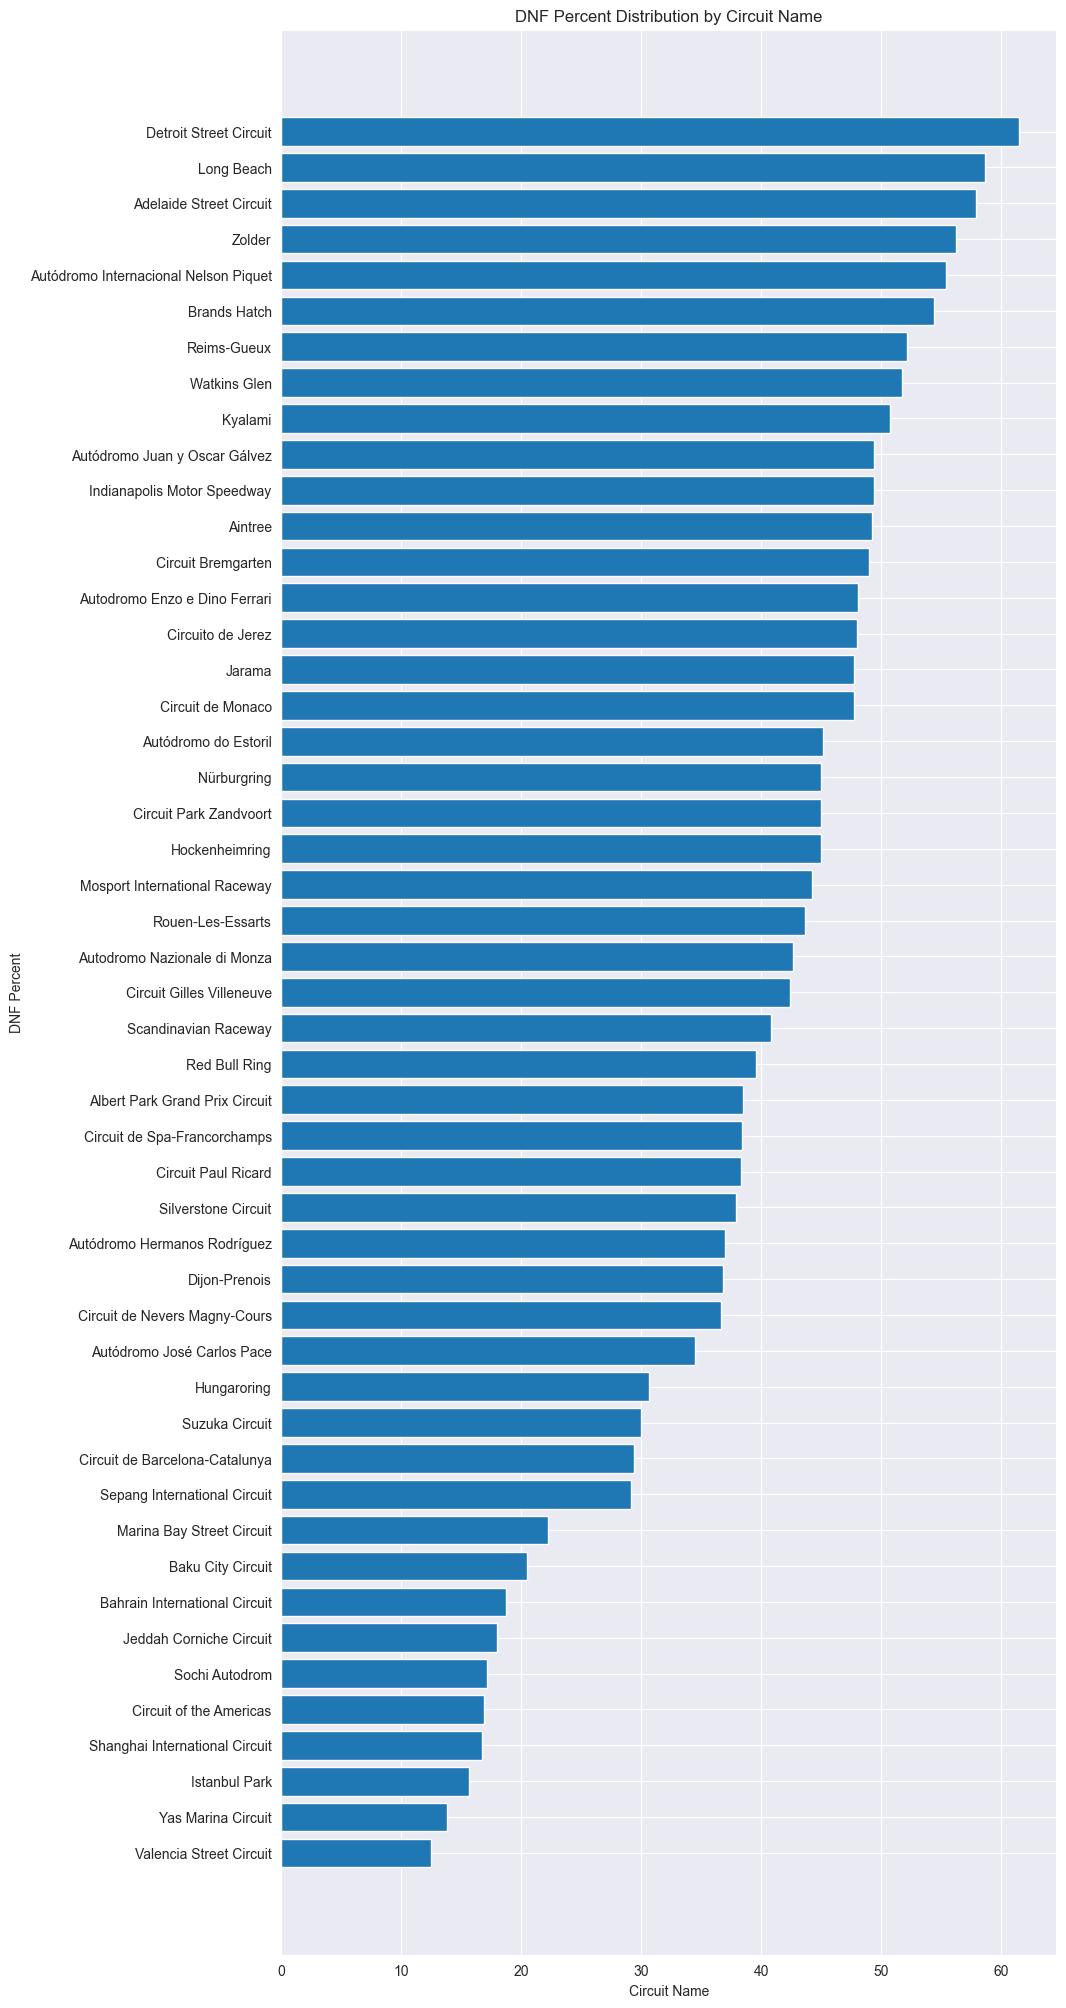

In [47]:
plt.figure(figsize = (10,25))
plt.barh(circuits_dnf['circuitName'], circuits_dnf['dnf_percent'])
plt.xlabel('Circuit Name')
plt.ylabel('DNF Percent')
plt.title('DNF Percent Distribution by Circuit Name')
plt.show()

This visualization aggregates all Formula 1 races across different eras.
High DNF rates on historical circuits largely reflect low car reliability
and safety standards of earlier decades rather than track layout alone.


## DNF Rates by Circuit Across Different Eras

Directly comparing DNF rates across all Formula 1 history can be misleading,
as car reliability, safety standards, and regulations have changed dramatically
over time.

To account for this, races are grouped into distinct technical eras, allowing
DNF patterns to be analyzed under more comparable conditions.

### Era Definitions

- **1950–1989 (Early Era)**
  Characterized by extremely low mechanical reliability and minimal safety
  standards. High DNF rates in this era primarily reflect technical failures
  rather than circuit characteristics.

- **1990–2004 (Modernization Era)**
  Improvements in car reliability and safety reduced overall DNFs, while circuit
  layout and race incidents began to play a more significant role.

- **2005–2013 (High Reliability Era)**
  Regulatory constraints increased car durability, shifting DNF causes away
  from mechanical failures toward race incidents and driver errors.

- **2014–Present (Hybrid Era)**
  The most reliable era in Formula 1 history. DNFs are relatively rare and often
  associated with accidents, strategic failures, or extreme conditions rather
  than baseline car reliability.

Analyzing DNF rates within each era allows circuit-related risk to be separated
from era-dependent technical limitations.


In [11]:
df = (
    results
    .merge(races[['raceId', 'year', 'name', 'circuitId']], on='raceId', how='left')
    .merge(status, on='statusId', how='left')
)

df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,name,circuitId,status
0,1,18,1,1,22,1,1,1,1,10.0,...,5690616,39,2,1:27.452,218.3,1,2008,Australian Grand Prix,1,Finished
1,2,18,2,2,3,5,2,2,2,8.0,...,5696094,41,3,1:27.739,217.586,1,2008,Australian Grand Prix,1,Finished
2,3,18,3,3,7,7,3,3,3,6.0,...,5698779,41,5,1:28.090,216.719,1,2008,Australian Grand Prix,1,Finished
3,4,18,4,4,5,11,4,4,4,5.0,...,5707797,58,7,1:28.603,215.464,1,2008,Australian Grand Prix,1,Finished
4,5,18,5,1,23,3,5,5,5,4.0,...,5708630,43,1,1:27.418,218.385,1,2008,Australian Grand Prix,1,Finished


In [12]:
early_era = df[df['year'] <= 1989]
modernization_era = df[(df['year'] > 1989) & (df['year'] <= 2004)]
high_reliability_era = df[(df['year'] > 2004) & (df['year'] <= 2013)]
hybrid_era = df[df['year'] > 2013]

In [13]:
eras_df = [early_era, modernization_era, high_reliability_era, hybrid_era]
eras_name = ["Early Era", "Modernization Era", "High Reliability Era", "Hybrid Era"]

In [14]:
early_era

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,name,circuitId,status
7873,7874,356,95,6,27,6,1,1,1,9.0,...,5938744,\N,\N,\N,\N,1,1989,Brazilian Grand Prix,36,Finished
7874,7875,356,117,1,2,5,2,2,2,6.0,...,5946553,\N,\N,\N,\N,1,1989,Brazilian Grand Prix,36,Finished
7875,7876,356,127,37,15,12,3,3,3,4.0,...,5948114,\N,\N,\N,\N,1,1989,Brazilian Grand Prix,36,Finished
7876,7877,356,65,22,20,10,4,4,4,3.0,...,5949237,\N,\N,\N,\N,1,1989,Brazilian Grand Prix,36,Finished
7877,7878,356,118,21,9,8,5,5,5,2.0,...,5956610,\N,\N,\N,\N,1,1989,Brazilian Grand Prix,36,Finished
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20318,20321,728,410,172,17,0,\N,W,22,0.0,...,\N,\N,\N,\N,\N,54,1963,South African Grand Prix,56,Withdrew
20319,20322,728,305,26,\N,0,\N,W,23,0.0,...,\N,\N,\N,\N,\N,54,1963,South African Grand Prix,56,Withdrew
24297,24303,745,418,172,21,15,11,11,11,0.0,...,\N,\N,\N,\N,\N,18,1961,United States Grand Prix,46,+8 Laps
24298,24304,717,373,172,2,1,\N,R,12,0.0,...,\N,\N,\N,\N,\N,98,1964,United States Grand Prix,46,Injection


In [15]:
from src.mapping import dnf_status_mapping, status_mapping

for i in eras_df:
    dnf_status_mapping(i)
    status_mapping(i)

In [16]:
early_era

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,rank,fastestLapTime,fastestLapSpeed,statusId,year,name,circuitId,status,dnfStatus,statusGroup
7873,7874,356,95,6,27,6,1,1,1,9.0,...,\N,\N,\N,1,1989,Brazilian Grand Prix,36,Finished,NaN,Finished
7874,7875,356,117,1,2,5,2,2,2,6.0,...,\N,\N,\N,1,1989,Brazilian Grand Prix,36,Finished,NaN,Finished
7875,7876,356,127,37,15,12,3,3,3,4.0,...,\N,\N,\N,1,1989,Brazilian Grand Prix,36,Finished,NaN,Finished
7876,7877,356,65,22,20,10,4,4,4,3.0,...,\N,\N,\N,1,1989,Brazilian Grand Prix,36,Finished,NaN,Finished
7877,7878,356,118,21,9,8,5,5,5,2.0,...,\N,\N,\N,1,1989,Brazilian Grand Prix,36,Finished,NaN,Finished
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20318,20321,728,410,172,17,0,\N,W,22,0.0,...,\N,\N,\N,54,1963,South African Grand Prix,56,Withdrew,Strategic / Race,DNF
20319,20322,728,305,26,\N,0,\N,W,23,0.0,...,\N,\N,\N,54,1963,South African Grand Prix,56,Withdrew,Strategic / Race,DNF
24297,24303,745,418,172,21,15,11,11,11,0.0,...,\N,\N,\N,18,1961,United States Grand Prix,46,+8 Laps,NaN,Finished
24298,24304,717,373,172,2,1,\N,R,12,0.0,...,\N,\N,\N,98,1964,United States Grand Prix,46,Injection,Mechanical Failure,DNF


### Early era

In [42]:
from src.aggregations import race_results_summary_by_accident, summary_accidents_by_circuits
summary_by_accident_early_era = race_results_summary_by_accident(early_era, circuits)
accident_by_circuits_early_era = summary_accidents_by_circuits(summary_by_accident_early_era)
accident_by_circuits_early_era

,circuitId,circuitName,total_started,dnf_count,accidents_count,mechanical_count,other_count,num_races,dnf_percent,accident_percent,mechanical_percent,other_percent
26,41,Dijon-Prenois,144,53,13,35,5,6,36.81,9.03,24.31,3.47
32,47,Scandinavian Raceway,147,60,15,43,2,6,40.82,10.20,29.25,1.36
8,18,Autódromo José Carlos Pace,160,66,18,47,1,7,41.25,11.25,29.38,0.62
38,53,Rouen-Les-Essarts,94,41,8,27,6,5,43.62,8.51,28.72,6.38
33,48,Mosport International Raceway,190,84,23,46,15,8,44.21,12.11,24.21,7.89
20,34,Circuit Paul Ricard,332,148,19,122,7,13,44.58,5.72,36.75,2.11
30,45,Jarama,201,96,20,71,5,9,47.76,9.95,35.32,2.49
13,25,Autódromo Juan y Oscar Gálvez,341,164,29,115,20,16,48.09,8.50,33.72,5.87
17,30,Kyalami,433,212,44,147,21,18,48.96,10.16,33.95,4.85
51,66,Circuit Bremgarten,100,49,9,38,2,5,49.00,9.00,38.00,2.00


### Modernization Era

In [43]:
summary_by_accident_modernization_era = race_results_summary_by_accident(modernization_era, circuits)
accident_by_circuits_modernization_era = summary_accidents_by_circuits(summary_by_accident_modernization_era)
accident_by_circuits_modernization_era

,circuitId,circuitName,total_started,dnf_count,accidents_count,mechanical_count,other_count,num_races,dnf_percent,accident_percent,mechanical_percent,other_percent
1,2,Sepang International Circuit,128,49,14,35,0,6,38.28,10.94,27.34,0.00
20,27,Autódromo do Estoril,172,66,27,36,3,7,38.37,15.70,20.93,1.74
15,20,Nürburgring,217,85,32,48,5,10,39.17,14.75,22.12,2.30
14,19,Indianapolis Motor Speedway,104,42,14,27,1,5,40.38,13.46,25.96,0.96
6,8,Circuit de Nevers Magny-Cours,317,130,45,82,3,14,41.01,14.20,25.87,0.95
7,9,Silverstone Circuit,344,142,42,93,7,15,41.28,12.21,27.03,2.03
9,11,Hungaroring,342,143,49,93,1,15,41.81,14.33,27.19,0.29
17,22,Suzuka Circuit,337,142,59,79,4,15,42.14,17.51,23.44,1.19
28,70,Red Bull Ring,152,66,19,43,4,7,43.42,12.50,28.29,2.63
10,13,Circuit de Spa-Francorchamps,323,141,56,81,4,14,43.65,17.34,25.08,1.24


### High Reliability Era

In [44]:
summary_by_accident_high_reliability_era = race_results_summary_by_accident(high_reliability_era, circuits)
accident_by_circuits_high_reliability = summary_accidents_by_circuits(summary_by_accident_high_reliability_era)
accident_by_circuits_high_reliability

,circuitId,circuitName,total_started,dnf_count,accidents_count,mechanical_count,other_count,num_races,dnf_percent,accident_percent,mechanical_percent,other_percent
11,12,Valencia Street Circuit,112,14,7,6,1,5,12.50,6.25,5.36,0.89
22,24,Yas Marina Circuit,114,18,10,7,1,5,15.79,8.77,6.14,0.88
13,14,Autodromo Nazionale di Monza,198,32,10,20,2,9,16.16,5.05,10.10,1.01
4,5,Istanbul Park,152,26,10,13,3,7,17.11,6.58,8.55,1.97
21,22,Suzuka Circuit,155,28,17,10,1,7,18.06,10.97,6.45,0.65
9,10,Hockenheimring,110,20,6,12,2,5,18.18,5.45,10.91,1.82
8,9,Silverstone Circuit,198,37,21,14,2,9,18.69,10.61,7.07,1.01
16,17,Shanghai International Circuit,198,38,20,14,4,9,19.19,10.10,7.07,2.02
17,18,Autódromo José Carlos Pace,198,40,22,14,4,9,20.20,11.11,7.07,2.02
2,3,Bahrain International Circuit,176,37,6,31,0,8,21.02,3.41,17.61,0.00


### Hybrid Era

In [45]:
summary_by_accident_hybrid_era = race_results_summary_by_accident(hybrid_era, circuits)
accident_by_circuits_hybrid = summary_accidents_by_circuits(summary_by_accident_hybrid_era)
accident_by_circuits_hybrid

,circuitId,circuitName,total_started,dnf_count,accidents_count,mechanical_count,other_count,num_races,dnf_percent,accident_percent,mechanical_percent,other_percent
21,39,Circuit Park Zandvoort,100,11,5,6,0,5,11.00,5.00,6.00,0.00
3,4,Circuit de Barcelona-Catalunya,243,27,12,15,0,12,11.11,4.94,6.17,0.00
17,22,Suzuka Circuit,204,25,15,7,3,10,12.25,7.35,3.43,1.47
18,24,Yas Marina Circuit,241,31,8,21,2,12,12.86,3.32,8.71,0.83
16,21,Autodromo Enzo e Dino Ferrari,99,13,7,5,1,5,13.13,7.07,5.05,1.01
13,17,Shanghai International Circuit,164,22,5,11,6,8,13.41,3.05,6.71,3.66
9,11,Hungaroring,244,33,16,13,4,12,13.52,6.56,5.33,1.64
11,14,Autodromo Nazionale di Monza,244,37,9,27,1,12,15.16,3.69,11.07,0.41
10,13,Circuit de Spa-Francorchamps,244,38,17,16,5,12,15.57,6.97,6.56,2.05
19,32,Autódromo Hermanos Rodríguez,202,32,13,15,4,10,15.84,6.44,7.43,1.98


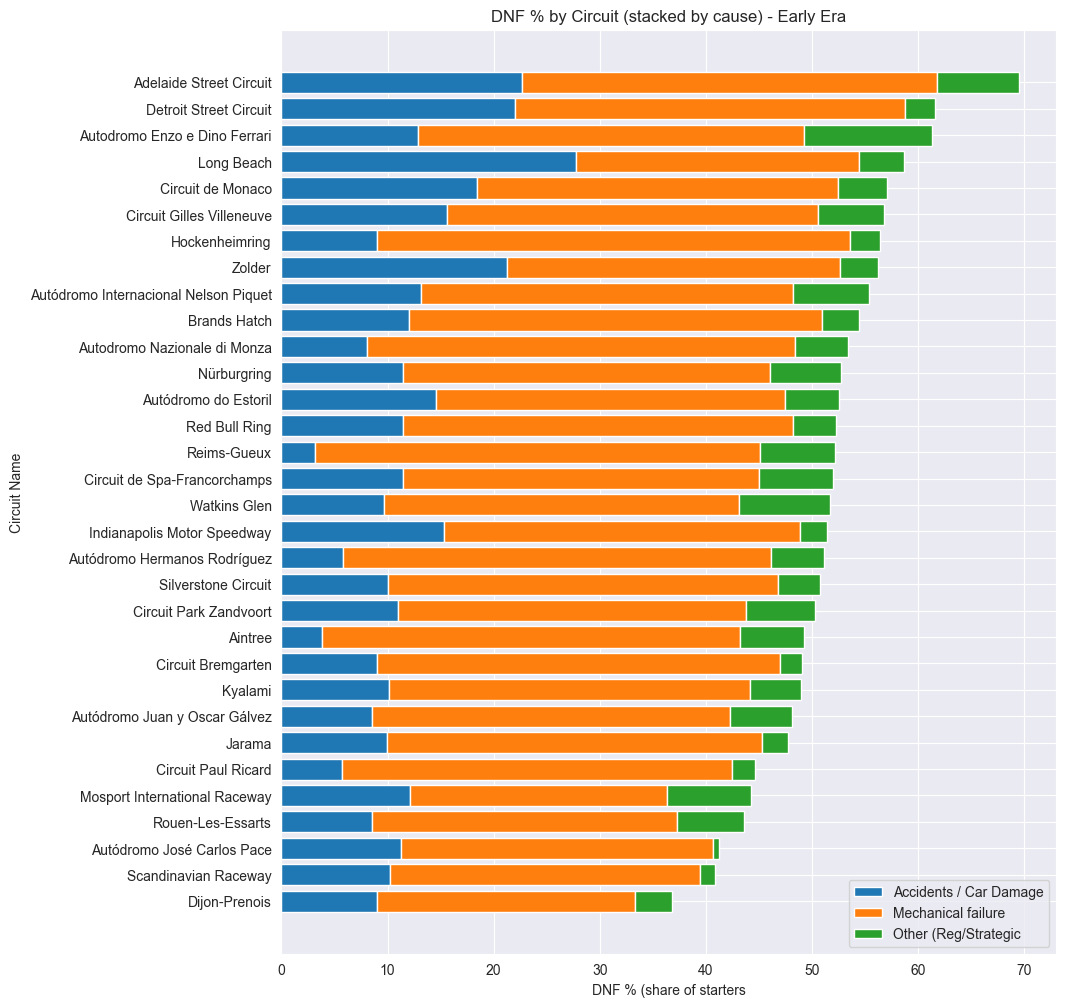

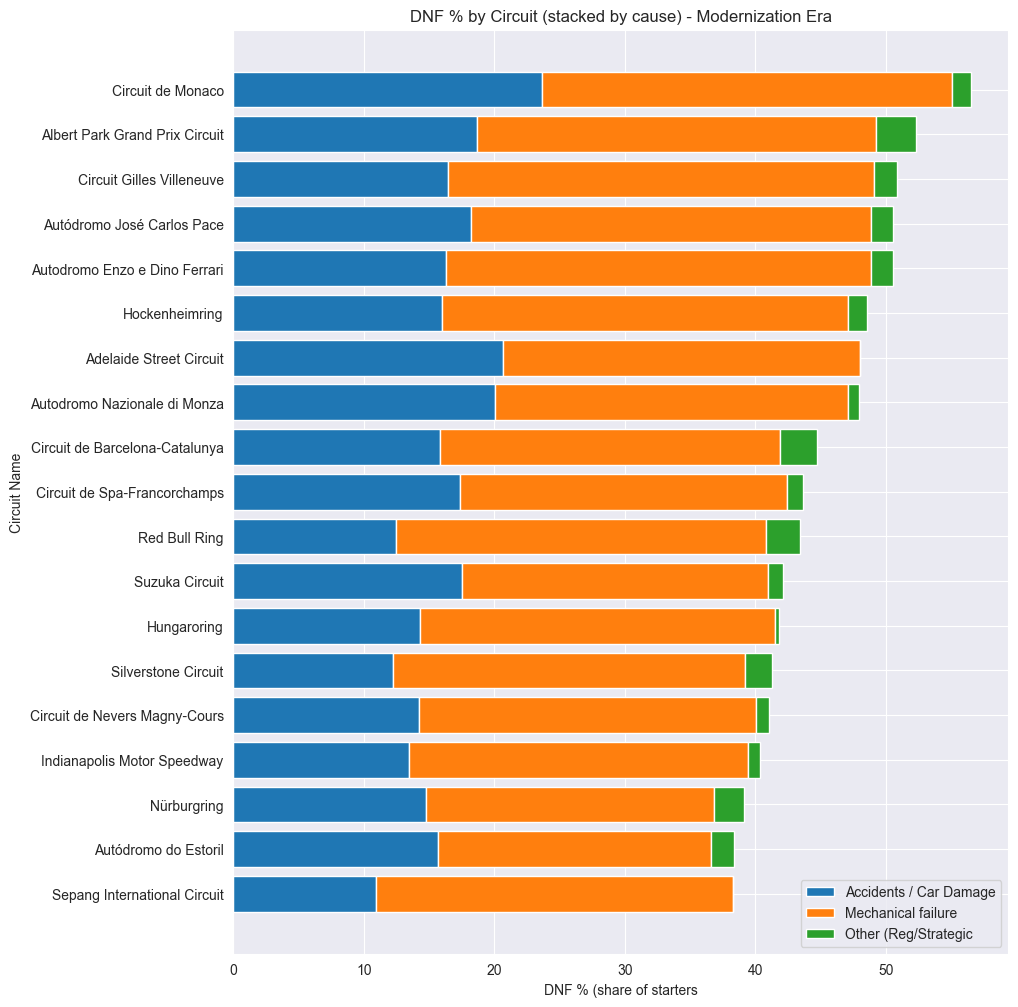

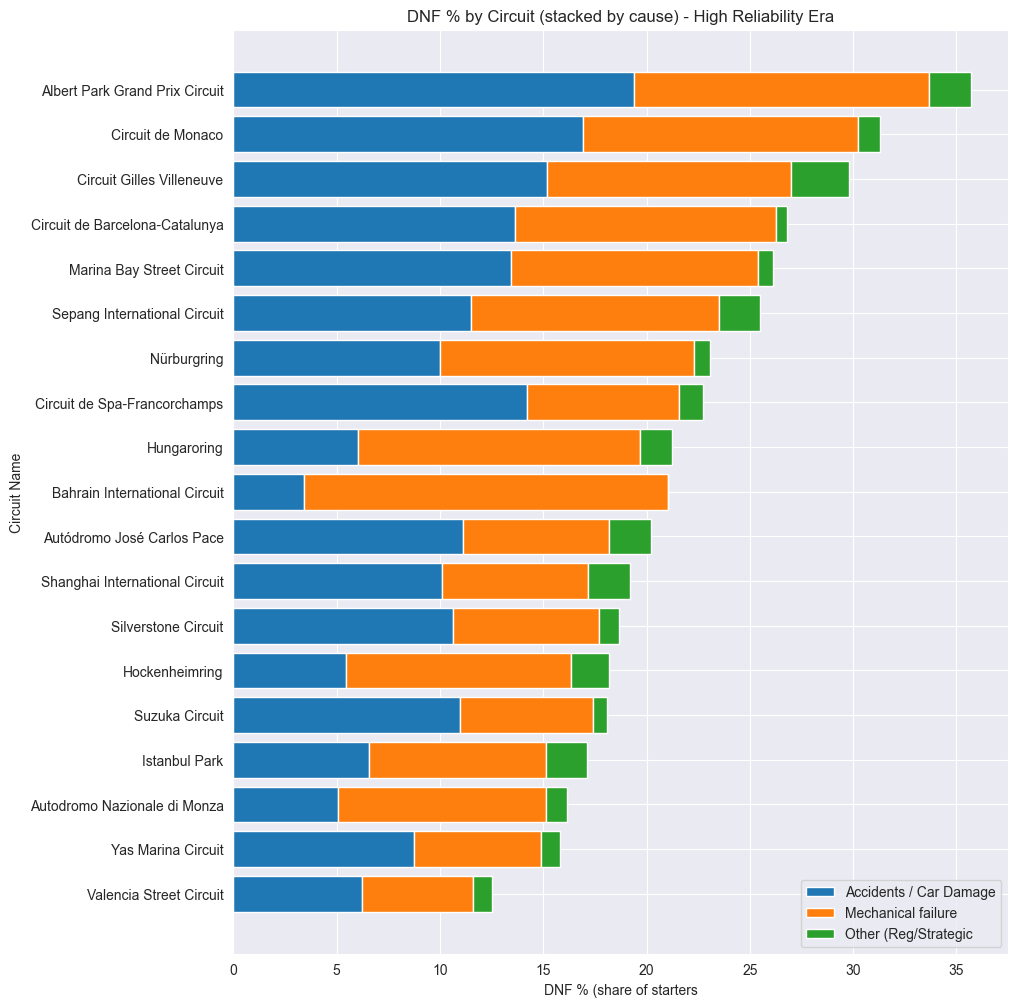

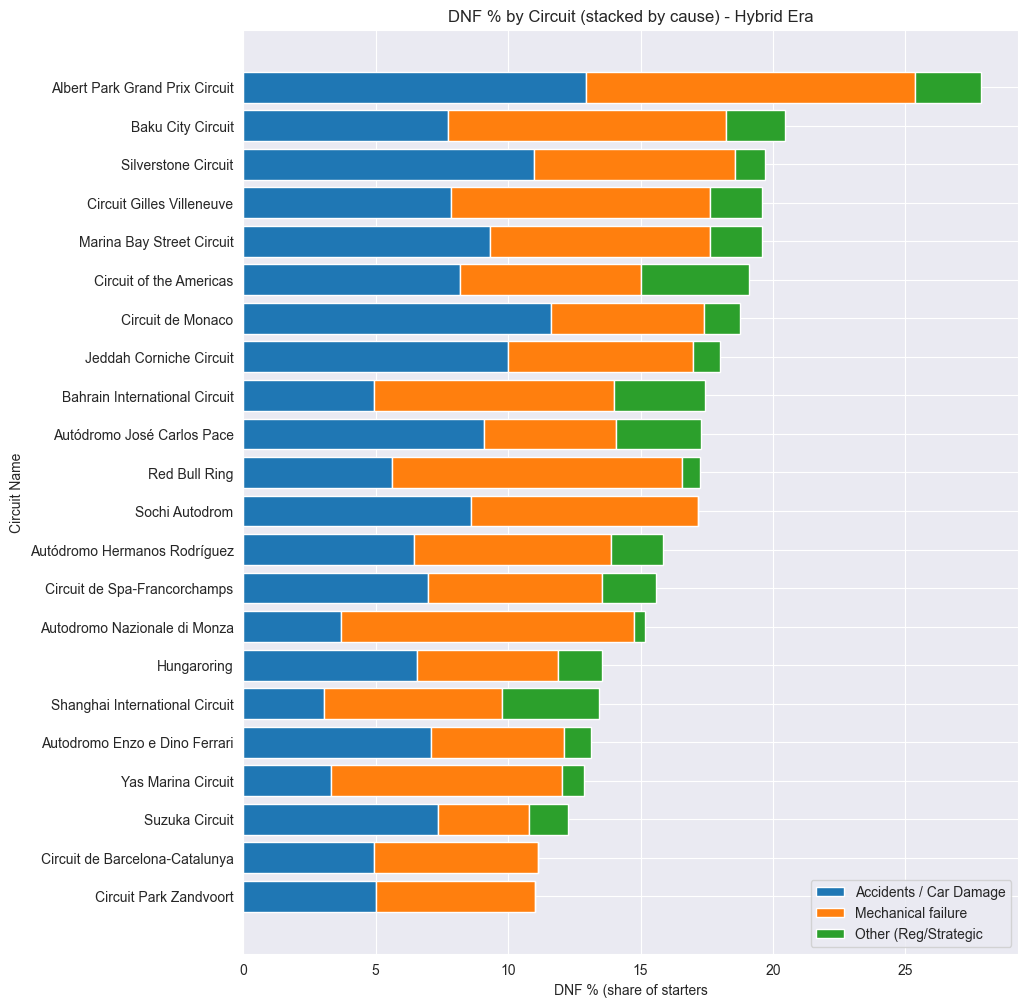

In [46]:
accident_by_circuits_eras = [accident_by_circuits_early_era, accident_by_circuits_modernization_era, accident_by_circuits_high_reliability, accident_by_circuits_hybrid]
names = ['Early Era', 'Modernization Era', 'High Reliability Era', 'Hybrid Era']

for data, name in zip(accident_by_circuits_eras, names):
    plot_dnf_percent_by_circuits(data, name)

## DNF Composition by Circuit and Era (Accident vs Mechanical)

The following stacked bar charts decompose **DNF percentages by circuit** into
three primary causes:
- Accident / Car damage
- Mechanical failure
- Other (regulatory or strategic reasons)

All values are expressed as a **percentage of race starters**, allowing direct
comparison between circuits within the same era.

---

### Early Era (1950–1989)

The Early Era is characterized by **extremely high DNF rates across most circuits**,
often exceeding 40–60% of starters.

Key observations:
- Mechanical failures dominate DNF composition on nearly all circuits
- Accident-related retirements represent a smaller but non-negligible share
- Differences between circuits are present, but largely secondary

**Interpretation:**
In this era, DNF rates primarily reflect **technological fragility** rather than
intrinsic circuit danger.
High DNF percentages should therefore not be interpreted as circuit-induced chaos,
but as a baseline feature of early Formula 1 machinery.

---

### Modernization Era (1990–2004)

During the Modernization Era, overall DNF rates decline, but remain substantial.

Key observations:
- Mechanical failures remain the leading cause of DNFs
- Accident-related retirements increase in relative importance
- Circuit-level differentiation becomes more visible, particularly on tighter
  or street-style layouts

**Interpretation:**
This period represents a **transition phase**, where improvements in reliability
allow circuit characteristics and race incidents to start influencing outcomes,
while technology remains a dominant failure source.

---

### High Reliability Era (2005–2013)

The High Reliability Era shows a further reduction in overall DNF rates.

Key observations:
- Mechanical and accident-related DNFs become more balanced
- Total DNF percentages drop significantly compared to earlier eras
- Differences between circuits become more interpretable

**Interpretation:**
At this stage, DNFs increasingly reflect **race dynamics and circuit layout**
rather than baseline mechanical unreliability.
Circuit-specific risk begins to play a meaningful role.

---

### Hybrid Era (2014–Present)

The Hybrid Era exhibits the lowest overall DNF rates in Formula 1 history.

Key observations:
- Mechanical failures are relatively rare and consistent across circuits
- Accident-related DNFs account for the majority of retirements
- Certain circuits consistently display higher incident-driven DNF shares

**Interpretation:**
In modern Formula 1, DNFs are predominantly **incident-driven**, making them a
valid proxy for race chaos — provided that causes are separated.
Mechanical reliability no longer dominates race outcomes.

---

### Cross-Era Insight

> High DNF rates do not universally imply a dangerous circuit.

- In early eras, DNFs are primarily driven by unreliable machinery
- In modern eras, DNFs increasingly reflect **circuit-induced incidents and race pressure**

This distinction is critical when comparing circuits historically or attempting
to quantify race chaos.

---

### Limitations

- Circuit presence varies by era; not all circuits appear in all periods
- DNF alone does not capture positional reshuffling among finishers
- Accident classification depends on historical status reporting accuracy

---

### Implications for Further Analysis

These findings motivate the introduction of **additional chaos metrics**, such as:
- position volatility
- finishing order dispersion
- safety car frequency

DNF captures **whether drivers retire**, but not **how unpredictable race outcomes
are among those who finish**.


## Race Chaos: Two Complementary Dimensions

The question of race chaos is not one-dimensional. A Formula 1 race can be chaotic
because many drivers fail to finish, but it can also be chaotic even when most drivers
finish — if the finishing order is strongly reshuffled relative to the starting grid.

To capture both aspects, this notebook defines **two complementary race-level metrics**:

---

### 1) Attrition Chaos (DNF-based)

**Definition:**
Attrition chaos measures how many starting drivers fail to finish the race.

**Metric:**
- **DNF rate** = DNF_count / total_started

**Interpretation:**
- High DNF rate → high attrition → structurally chaotic race (high failure / incidents)
- Low DNF rate → clean race in terms of survival

This metric captures chaos through **race survival**, but it does not describe whether the
competitive order was disrupted among those who finished.

---

### 2) Order Disruption (Grid → Finish reshuffling)

**Definition:**
Order disruption measures how strongly the race outcome differs from the expected order
implied by the starting grid (qualifying position).

**Core idea:**
If a race is predictable, drivers tend to finish close to their starting positions.
If a race is chaotic, many drivers finish far from where they started.

**Example metrics (race-level):**
- **Mean Absolute Position Change**: average(|finish_position − grid_position|)
- **Median Absolute Position Change**
- **Rank correlation (Spearman)** between grid positions and finish positions
  (higher correlation → more predictable race; lower correlation → more chaotic)

**Interpretation:**
- Large average position change and/or low grid-finish correlation → high order disruption
- Small position changes and/or high correlation → predictable race

This metric captures chaos through **competitive reshuffling**, independent of DNFs.

---

### Why both metrics are needed

These two dimensions describe different race behaviors:

- A race can have **high DNF** but still be orderly among survivors (attrition without reshuffling).
- A race can have **low DNF** but still be chaotic in the standings (clean race with strong reshuffling).
- The most chaotic races combine both: high attrition and strong order disruption.

The analysis therefore treats race chaos as a two-axis concept rather than a single score.


In [58]:
from pathlib import Path
from config.dnf_groups import STATUS_FINISHED
status_mapping = {}
for group_name, ids in STATUS_FINISHED.items():
    for s_id in ids:
        status_mapping[s_id] = group_name

df['statusGroup'] = df['statusId'].map(status_mapping)


race_results_driver_level = df.copy()
out_path = Path("../data/processed/race_results_driver_level.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)

race_results_driver_level.to_csv(out_path, index=False)


In [59]:
race_results_driver_level.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,name,circuitId,status,statusGroup
0,1,18,1,1,22,1,1,1,1,10.0,...,39,2,1:27.452,218.3,1,2008,Australian Grand Prix,1,Finished,Finished
1,2,18,2,2,3,5,2,2,2,8.0,...,41,3,1:27.739,217.586,1,2008,Australian Grand Prix,1,Finished,Finished
2,3,18,3,3,7,7,3,3,3,6.0,...,41,5,1:28.090,216.719,1,2008,Australian Grand Prix,1,Finished,Finished
3,4,18,4,4,5,11,4,4,4,5.0,...,58,7,1:28.603,215.464,1,2008,Australian Grand Prix,1,Finished,Finished
4,5,18,5,1,23,3,5,5,5,4.0,...,43,1,1:27.418,218.385,1,2008,Australian Grand Prix,1,Finished,Finished


In [60]:
race_results_driver_level.columns

Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps', 'time',
       'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
       'fastestLapSpeed', 'statusId', 'year', 'name', 'circuitId', 'status',
       'statusGroup'],
      dtype='str')

In [65]:
import numpy as np
import pandas as pd

race_results_for_chaos = race_results_driver_level[
    ['raceId', 'year', 'name', 'grid', 'positionOrder', 'statusGroup']
].copy()

race_results_for_chaos = race_results_for_chaos[
    race_results_for_chaos['statusGroup'] != 'NotFinishedNotDNF'
].copy()

race_results_for_chaos = race_results_for_chaos.rename(columns={'name': 'gp_name'})

race_results_for_chaos[['grid', 'positionOrder']] = race_results_for_chaos[['grid', 'positionOrder']].replace(r'\\N', np.nan)

race_results_for_chaos['grid'] = pd.to_numeric(race_results_for_chaos['grid'], errors='coerce')
race_results_for_chaos['positionOrder'] = pd.to_numeric(race_results_for_chaos['positionOrder'], errors='coerce')

race_results_for_chaos.head()


,raceId,year,gp_name,grid,positionOrder,statusGroup
0,18,2008,Australian Grand Prix,1.0,1,Finished
1,18,2008,Australian Grand Prix,5.0,2,Finished
2,18,2008,Australian Grand Prix,7.0,3,Finished
3,18,2008,Australian Grand Prix,11.0,4,Finished
4,18,2008,Australian Grand Prix,3.0,5,Finished


In [72]:
race_results_starters = race_results_for_chaos[race_results_for_chaos['grid'].notna() & (race_results_for_chaos['grid'] > 0)].copy()

race_results_finishers = race_results_for_chaos[
    (race_results_for_chaos['statusGroup'] == 'Finished') &
    race_results_for_chaos['grid'].notna() & (race_results_for_chaos['grid'] > 0) &
    race_results_for_chaos['positionOrder'].notna()
].copy()
race_results_finishers

,raceId,year,gp_name,grid,positionOrder,statusGroup
0,18,2008,Australian Grand Prix,1.0,1,Finished
1,18,2008,Australian Grand Prix,5.0,2,Finished
2,18,2008,Australian Grand Prix,7.0,3,Finished
3,18,2008,Australian Grand Prix,11.0,4,Finished
4,18,2008,Australian Grand Prix,3.0,5,Finished
...,...,...,...,...,...,...
27233,1168,2025,Abu Dhabi Grand Prix,17.0,16,Finished
27234,1168,2025,Abu Dhabi Grand Prix,9.0,17,Finished
27235,1168,2025,Abu Dhabi Grand Prix,13.0,18,Finished
27236,1168,2025,Abu Dhabi Grand Prix,19.0,19,Finished


In [71]:
dnf_by_race = (
    race_results_starters
    .groupby(['raceId'])
    .agg(
        year = ('year', 'first'),
        gp_name = ('gp_name', 'first'),
        total_started = ('statusGroup', 'count'),
        dnf_count = ('statusGroup', lambda x: (x == 'DNF').sum())
    )
    .reset_index()
)

dnf_by_race['dnf_rate'] = (dnf_by_race['dnf_count'] / dnf_by_race['total_started']).round(3)
dnf_by_race

,raceId,year,gp_name,total_started,dnf_count,dnf_rate
0,1,2009,Australian Grand Prix,20,8,0.40
1,2,2009,Malaysian Grand Prix,20,5,0.25
2,3,2009,Chinese Grand Prix,20,4,0.20
3,4,2009,Bahrain Grand Prix,20,1,0.05
4,5,2009,Spanish Grand Prix,20,6,0.30
...,...,...,...,...,...,...
1143,1163,2025,United States Grand Prix,20,1,0.05
1144,1164,2025,Mexico City Grand Prix,20,4,0.20
1145,1165,2025,São Paulo Grand Prix,20,3,0.15
1146,1166,2025,Las Vegas Grand Prix,20,5,0.25


In [84]:
race_results_finishers['abs_position_change'] = (
    race_results_finishers['grid'] - race_results_finishers['positionOrder']
).abs()
order_disruption_by_race = (
    race_results_finishers
    .groupby(['raceId'])
    .agg(
        order_disruption = ('abs_position_change', 'mean')
    )
    .reset_index()
)

order_disruption_by_race['order_disruption'] = (
    order_disruption_by_race['order_disruption'].round(3)
)
order_disruption_by_race

,raceId,order_disruption
0,1,5.750
1,2,3.400
2,3,3.688
3,4,3.158
4,5,2.500
...,...,...
1143,1163,2.474
1144,1164,3.000
1145,1165,2.529
1146,1166,4.800


In [85]:
race_chaos = dnf_by_race.merge(
    order_disruption_by_race,
    how='left',
    on='raceId'
)

race_chaos

,raceId,year,gp_name,total_started,dnf_count,dnf_rate,order_disruption
0,1,2009,Australian Grand Prix,20,8,0.40,5.750
1,2,2009,Malaysian Grand Prix,20,5,0.25,3.400
2,3,2009,Chinese Grand Prix,20,4,0.20,3.688
3,4,2009,Bahrain Grand Prix,20,1,0.05,3.158
4,5,2009,Spanish Grand Prix,20,6,0.30,2.500
...,...,...,...,...,...,...,...
1143,1163,2025,United States Grand Prix,20,1,0.05,2.474
1144,1164,2025,Mexico City Grand Prix,20,4,0.20,3.000
1145,1165,2025,São Paulo Grand Prix,20,3,0.15,2.529
1146,1166,2025,Las Vegas Grand Prix,20,5,0.25,4.800


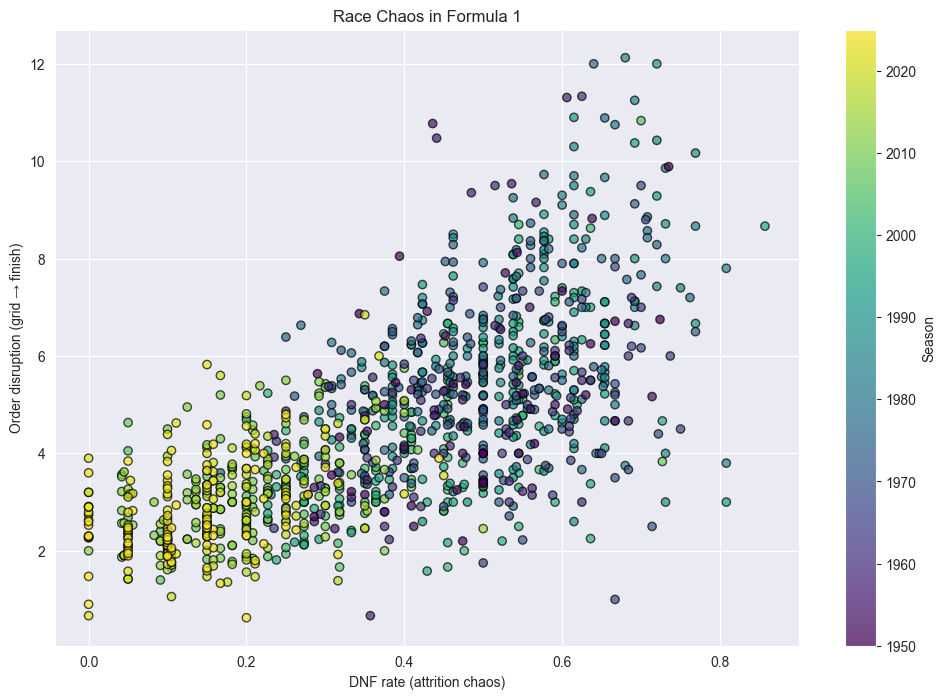

In [86]:
plt.figure(figsize=(12, 8))

sc = plt.scatter(
    race_chaos['dnf_rate'],
    race_chaos['order_disruption'],
    c=race_chaos['year'],
    cmap='viridis',
    alpha=0.7,
    edgecolor='k'
)

plt.xlabel('DNF rate (attrition chaos)')
plt.ylabel('Order disruption (grid → finish)')
plt.title('Race Chaos in Formula 1')

cbar = plt.colorbar(sc)
cbar.set_label('Season')

plt.show()


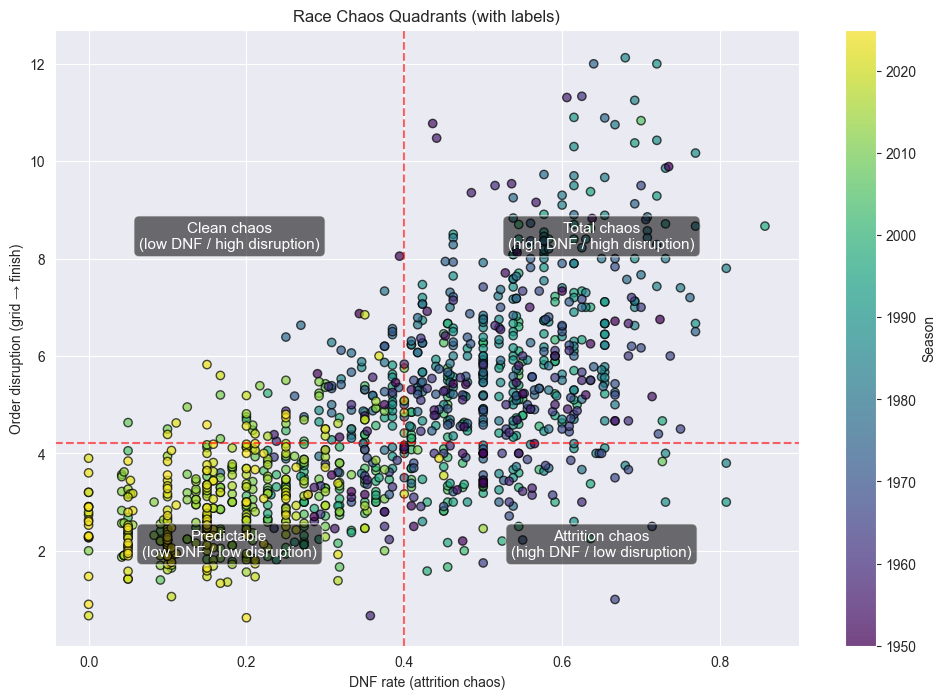

In [89]:
dnf_thr = race_chaos['dnf_rate'].median()
dis_thr = race_chaos['order_disruption'].median()

plt.figure(figsize=(12, 8))

sc = plt.scatter(
    race_chaos['dnf_rate'],
    race_chaos['order_disruption'],
    c=race_chaos['year'],
    cmap='viridis',
    alpha=0.7,
    edgecolor='k'
)

plt.axvline(dnf_thr, color='red', linestyle='--', alpha=0.6)
plt.axhline(dis_thr, color='red', linestyle='--', alpha=0.6)

plt.xlabel('DNF rate (attrition chaos)')
plt.ylabel('Order disruption (grid → finish)')
plt.title('Race Chaos Quadrants (with labels)')

x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()

x_left  = (x_min + dnf_thr) / 2
x_right = (dnf_thr + x_max) / 2
y_low   = (y_min + dis_thr) / 2
y_high  = (dis_thr + y_max) / 2

bbox = dict(boxstyle="round,pad=0.35", fc="black", ec="white", alpha=0.55)



plt.text(x_left,  y_low,  'Predictable\n(low DNF / low disruption)',
         ha='center', va='center', fontsize=11, color='white', bbox=bbox)

plt.text(x_right, y_low,  'Attrition chaos\n(high DNF / low disruption)',
         ha='center', va='center', fontsize=11, color='white', bbox=bbox)

plt.text(x_left,  y_high, 'Clean chaos\n(low DNF / high disruption)',
         ha='center', va='center', fontsize=11, color='white', bbox=bbox)

plt.text(x_right, y_high, 'Total chaos\n(high DNF / high disruption)',
         ha='center', va='center', fontsize=11, color='white', bbox=bbox)


cbar = plt.colorbar(sc)
cbar.set_label('Season')

plt.show()


## Race Chaos in Formula 1

### Research question
**How chaotic or predictable was a given Formula 1 race?**

To answer this question, we decompose race chaos into two independent dimensions:

1. **Attrition chaos** — how many drivers failed to finish the race
2. **Order disruption chaos** — how much the finishing order differed from the starting grid

This allows us to separate races that were chaotic due to reliability issues from races that were chaotic due to on-track position changes.

---

## Metrics definition

### 1. DNF rate (attrition chaos)

\[
\text{DNF rate} = \frac{\text{Number of DNFs}}{\text{Number of starters}}
\]

This metric captures **mechanical unreliability, accidents, and general race attrition**.

- Low DNF rate → reliable, stable races
- High DNF rate → unreliable, survival-based races

---

### 2. Order disruption (position volatility)

For each driver who finished the race:

\[
\text{Absolute position change} = | \text{grid position} - \text{finishing position} |
\]

For each race, we compute:

\[
\text{Order disruption} = \text{mean absolute position change among finishers}
\]

This metric captures **how much the race order was reshuffled**, regardless of DNFs.

- Low values → races where drivers finish close to their starting positions
- High values → races with overtaking, strategy variance, and on-track chaos

---

## Combined race chaos visualization

The scatter plot below shows **each race as a point**, positioned by:

- **X-axis:** DNF rate (attrition chaos)
- **Y-axis:** Order disruption (grid → finish volatility)
- **Color:** Season (year)

This allows us to visually compare races across eras and identify different types of chaos.

---

## Chaos quadrants interpretation

Using the median values of both metrics, races are divided into four quadrants:

### 🟢 Predictable races
**Low DNF / Low disruption**

- Reliable cars
- Stable finishing order
- Typical of modern, controlled races

---

### 🟡 Clean chaos
**Low DNF / High disruption**

- Most drivers finish
- Significant reshuffling of positions
- Strategy, overtaking, and racecraft-driven chaos

---

### 🟠 Attrition chaos
**High DNF / Low disruption**

- Many retirements
- Finishing order stabilizes early
- Survivorship rather than racing determines results

---

### 🔴 Total chaos
**High DNF / High disruption**

- Unreliable cars
- Frequent incidents
- Massive order reshuffles
- Classic “anything can happen” races

---

## Key insights

- Race chaos is **not one-dimensional** — DNFs alone do not explain unpredictability.
- Some races are chaotic despite low attrition, driven purely by on-track dynamics.
- Older eras tend to populate the **high DNF regions**, while modern races cluster in the **predictable quadrant**.
- This framework allows objective comparison of races, circuits, and eras using the same chaos definition.

---

## Why this matters

This approach provides a **quantitative answer** to the question:

> *Was this race chaotic, and if so — why?*

It also creates a foundation for:
- Era-level chaos comparison
- Circuit-level chaos profiling
- Identifying historically “wild” races
- Comparing regulation changes through chaos dynamics


In [90]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1) Define eras (adjust boundaries if you want) ---
def year_to_era(y: int) -> str:

    if y <= 1989:
        return "Early Era"
    elif y <= 2004 and y > 1989:
        return "Modernization Era"
    elif y <= 2013 and y > 2004:
        return "High Reliability Era"
    else:
        return "Hybrid Era"

race_chaos = race_chaos.copy()
race_chaos["year"] = race_chaos["year"].astype(int)
race_chaos["era"] = race_chaos["year"].apply(year_to_era)



In [91]:
dnf_thr = race_chaos["dnf_rate"].median()
dis_thr = race_chaos["order_disruption"].median()

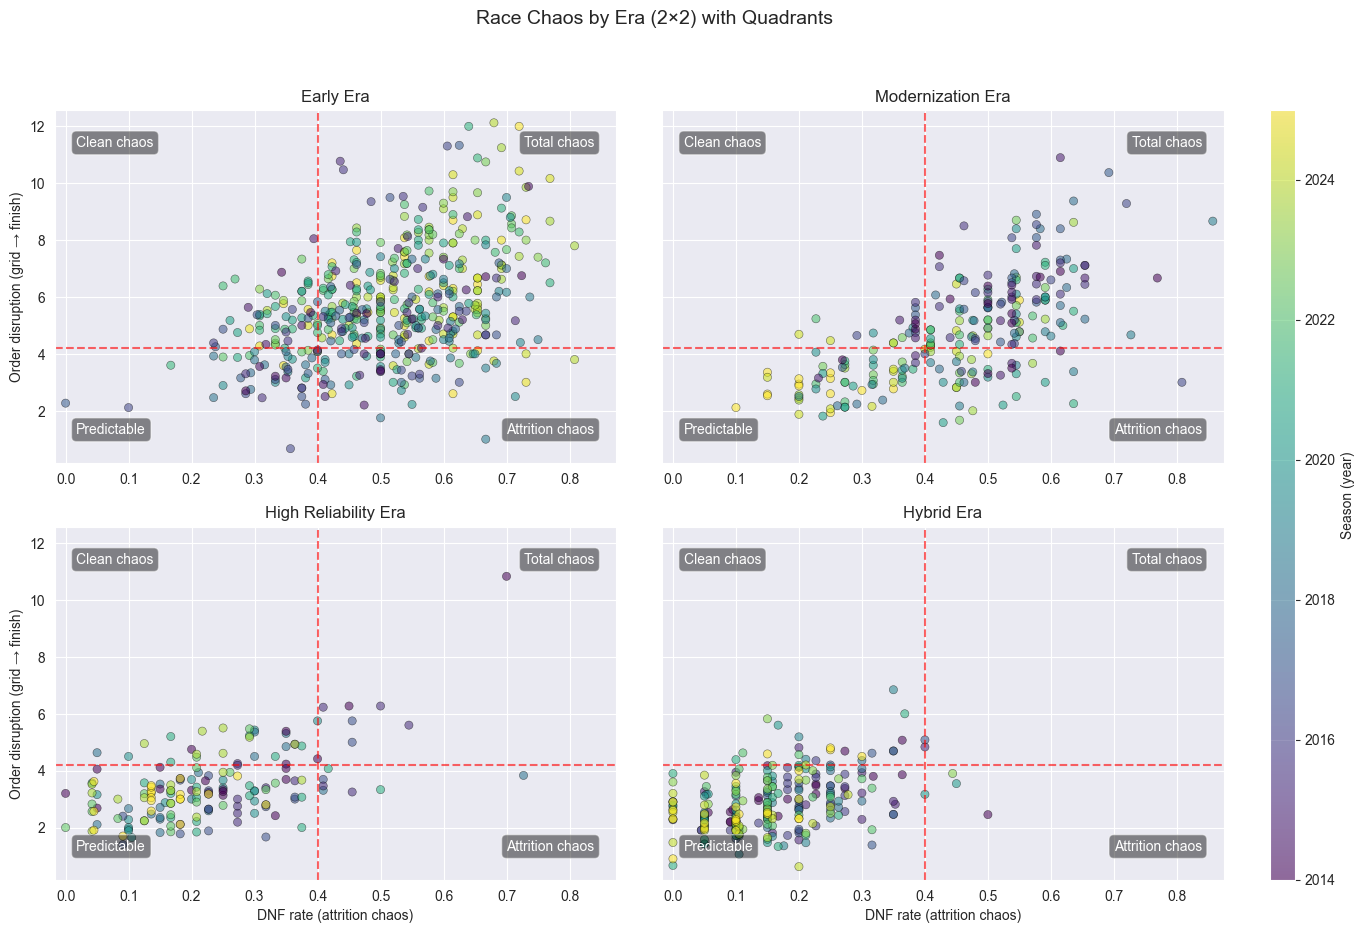

In [93]:
era_order = [
    ("Early Era", (0, 0)),
    ("Modernization Era", (0, 1)),
    ("High Reliability Era", (1, 0)),
    ("Hybrid Era", (1, 1)),
]


# --- figure with a dedicated colorbar column (no overlap) ---
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(nrows=2, ncols=3, width_ratios=[1, 1, 0.045], wspace=0.12, hspace=0.18)

axes = np.array([
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]
])

cax = fig.add_subplot(gs[:, 2])  # colorbar axis spanning both rows

# shared limits
x_min, x_max = race_chaos["dnf_rate"].min(), race_chaos["dnf_rate"].max()
y_min, y_max = race_chaos["order_disruption"].min(), race_chaos["order_disruption"].max()
x_pad = 0.02 * (x_max - x_min)
y_pad = 0.04 * (y_max - y_min)

bbox = dict(boxstyle="round,pad=0.35", fc="black", ec="white", alpha=0.45)

sc = None  # will keep last scatter for colorbar

for era_name, (r, c) in era_order:
    ax = axes[r, c]
    df_e = race_chaos[race_chaos["era"] == era_name].copy()

    sc = ax.scatter(
        df_e["dnf_rate"],
        df_e["order_disruption"],
        c=df_e["year"],
        cmap="viridis",
        alpha=0.55,
        edgecolor="k",
        s=35,
        linewidth=0.4
    )

    ax.axvline(dnf_thr, color="red", linestyle="--", alpha=0.6)
    ax.axhline(dis_thr, color="red", linestyle="--", alpha=0.6)

    ax.set_title(era_name)
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    ax.text(x_min + x_pad, y_max - y_pad, "Clean chaos", ha="left", va="top",
            color="white", bbox=bbox, fontsize=10)
    ax.text(x_max - x_pad, y_max - y_pad, "Total chaos", ha="right", va="top",
            color="white", bbox=bbox, fontsize=10)
    ax.text(x_min + x_pad, y_min + y_pad, "Predictable", ha="left", va="bottom",
            color="white", bbox=bbox, fontsize=10)
    ax.text(x_max - x_pad, y_min + y_pad, "Attrition chaos", ha="right", va="bottom",
            color="white", bbox=bbox, fontsize=10)

# outer axis labels
axes[1, 0].set_xlabel("DNF rate (attrition chaos)")
axes[1, 1].set_xlabel("DNF rate (attrition chaos)")
axes[0, 0].set_ylabel("Order disruption (grid → finish)")
axes[1, 0].set_ylabel("Order disruption (grid → finish)")

# clean: remove repeated y tick labels on right column
axes[0, 1].tick_params(labelleft=False)
axes[1, 1].tick_params(labelleft=False)

# colorbar in dedicated axis (no overlap)
cbar = fig.colorbar(sc, cax=cax)
cbar.set_label("Season (year)")

fig.suptitle("Race Chaos by Era (2×2) with Quadrants", y=0.98, fontsize=14)
plt.show()


In [94]:
race_chaos

,raceId,year,gp_name,total_started,dnf_count,dnf_rate,order_disruption,era
0,1,2009,Australian Grand Prix,20,8,0.40,5.750,High Reliability Era
1,2,2009,Malaysian Grand Prix,20,5,0.25,3.400,High Reliability Era
2,3,2009,Chinese Grand Prix,20,4,0.20,3.688,High Reliability Era
3,4,2009,Bahrain Grand Prix,20,1,0.05,3.158,High Reliability Era
4,5,2009,Spanish Grand Prix,20,6,0.30,2.500,High Reliability Era
...,...,...,...,...,...,...,...,...
1143,1163,2025,United States Grand Prix,20,1,0.05,2.474,Hybrid Era
1144,1164,2025,Mexico City Grand Prix,20,4,0.20,3.000,Hybrid Era
1145,1165,2025,São Paulo Grand Prix,20,3,0.15,2.529,Hybrid Era
1146,1166,2025,Las Vegas Grand Prix,20,5,0.25,4.800,Hybrid Era
